In [1]:
import importlib
import sys
import pickle
import numpy as np

sys.path.insert(0, '..')
sys.path.insert(0, '../..')
sys.path.insert(0, '../../..')
sys.path.insert(0, '../../../..')
sys.path.insert(0, '../../../../..')

In [2]:
import src.evaluation_metrics.conduct_evaluation
importlib.reload(src.evaluation_metrics.conduct_evaluation)

import src.evaluation_metrics.metrics
importlib.reload(src.evaluation_metrics.metrics)

<module 'src.evaluation_metrics.metrics' from '/home/PSPLab/ProbabilisticSuffixPredictionLab/probabilistic_suffix_prediction_U-ED-LSTM/src/notebooks/evaluation_metric_notebooks/version_2_conformal/Sepsis/../../../../../src/evaluation_metrics/metrics.py'>

In [3]:
import src.evaluation_metrics.plots
importlib.reload(src.evaluation_metrics.plots)

output_dirs = ['../../../../../../../data/Sepsis/v2_conformal/']

all_results = dict()

event_label_list = ['ER Registration', 'Leucocytes', 'CRP', 'LacticAcid', 'ER Triage', 'ER Sepsis Triage', 'IV Liquid', 'IV Antibiotics', 'Admission NC',
                    'Release A', 'Return ER', 'Admission IC', 'Release B', 'Release C', 'Release D', 'Release E']

for output_dir in output_dirs:
    evaluation_metrics = {
        'NormalizedDamerauLevenshteinMeanVar_activity' : src.evaluation_metrics.metrics.NormalizedDamerauLevenshteinDistanceMeanVar('concept:name', percentile=0.25),
        'RemainingTime_SUM_Mean_MAE_outliers' : src.evaluation_metrics.metrics.SumValueMeanMAE('event_elapsed_time', percentile=0.25, value_factor = 3600*24),
        'RemainingTime_SUM_Abs_Mean_MAE_outliers' : src.evaluation_metrics.metrics.SumAbsValueMeanMAE('event_elapsed_time', percentile=0.25, value_factor = 3600*24),
        'RemainingTime_LastEvent_Mean2_Var_seconds_outliers' : src.evaluation_metrics.metrics.LastValueMean2VarMAE('case_elapsed_time', percentile=0.25, value_factor= 3600*24),
        'RemainingTime_PIT' : src.evaluation_metrics.metrics.LastValuePIT('case_elapsed_time'),
        'EventElapsed_PIT' : src.evaluation_metrics.metrics.SumValuesPIT('event_elapsed_time'),
        'SuffixCountMAE' : src.evaluation_metrics.metrics.SuffixCountMAE(percentile=0.25),
        
        'SumValuesInterval_50' : src.evaluation_metrics.metrics.SumValuesInterval('event_elapsed_time', percentile=0.5),
        'SumValuesInterval_75' : src.evaluation_metrics.metrics.SumValuesInterval('event_elapsed_time', percentile=0.75),
        #'SumValuesInterval_90' : src.evaluation_metrics.metrics.SumValuesInterval('event_elapsed_time', percentile=0.90),
        'SumValuesInterval_95' : src.evaluation_metrics.metrics.SumValuesInterval('event_elapsed_time', percentile=0.95),
        #'SumValuesInterval_99' : src.evaluation_metrics.metrics.SumValuesInterval('event_elapsed_time', percentile=0.99),

        'LastValueInterval_50' : src.evaluation_metrics.metrics.LastValueInterval('case_elapsed_time', percentile=0.50),
        'LastValueInterval_75' : src.evaluation_metrics.metrics.LastValueInterval('case_elapsed_time', percentile=0.75),
        #'LastValueInterval_90' : src.evaluation_metrics.metrics.LastValueInterval('case_elapsed_time', percentile=0.90),
        'LastValueInterval_95' : src.evaluation_metrics.metrics.LastValueInterval('case_elapsed_time', percentile=0.95),
        #'LastValueInterval_99' : src.evaluation_metrics.metrics.LastValueInterval('case_elapsed_time', percentile=0.99),

        'SuffixCountInterval_50' : src.evaluation_metrics.metrics.SuffixCountInterval(percentile=0.50),
        'SuffixCountInterval_75' : src.evaluation_metrics.metrics.SuffixCountInterval(percentile=0.75),
        #'SuffixCountInterval_90' : src.evaluation_metrics.metrics.SuffixCountInterval(percentile=0.90),
        'SuffixCountInterval_95' : src.evaluation_metrics.metrics.SuffixCountInterval(percentile=0.95),
        #'SuffixCountInterval_99' : src.evaluation_metrics.metrics.SuffixCountInterval(percentile=0.99),

        'EventLabelCountInterval_50' : src.evaluation_metrics.metrics.EventLabelCountInterval('concept:name', event_label_list, percentile=0.50),
        'EventLabelCountInterval_75' : src.evaluation_metrics.metrics.EventLabelCountInterval('concept:name', event_label_list, percentile=0.75),
        #'EventLabelCountInterval_90' : src.evaluation_metrics.metrics.EventLabelCountInterval('concept:name', event_label_list, percentile=0.90),
        'EventLabelCountInterval_95' : src.evaluation_metrics.metrics.EventLabelCountInterval('concept:name', event_label_list, percentile=0.95),
        #'EventLabelCountInterval_99' : src.evaluation_metrics.metrics.EventLabelCountInterval('concept:name', event_label_list, percentile=0.99),
    }

    res_raw, c = src.evaluation_metrics.conduct_evaluation.batch_evaluate(output_dir, evaluation_metrics)
    # res_raw, c = src.evaluation_metrics.conduct_evaluation.evaluate_sequentially(output_dir, evaluation_metrics)
    all_results[output_dir] = (res_raw, c)

with open("Sepsis_eval.pkl", "wb") as file:
    pickle.dump(all_results, file)

Loaded: results_part_1000.pkl
Loaded: results_part_050.pkl
Loaded: results_part_100.pkl
Loaded: results_part_1050.pkl
Loaded: results_part_1100.pkl
Loaded: results_part_1150.pkl
Loaded: results_part_1200.pkl
Loaded: results_part_1250.pkl
Loaded: results_part_1350.pkl
Loaded: results_part_1300.pkl
Loaded: results_part_1400.pkl
Loaded: results_part_1450.pkl
Loaded: results_part_150.pkl
Loaded: results_part_1500.pkl
Loaded: results_part_1550.pkl
Loaded: results_part_1600.pkl
Loaded: results_part_1650.pkl
Loaded: results_part_1700.pkl
Loaded: results_part_1750.pkl
Loaded: results_part_1800.pkl
Loaded: results_part_1850.pkl
Loaded: results_part_1900.pkl
Loaded: results_part_1950.pkl
Loaded: results_part_1997.pkl
Loaded: results_part_200.pkl
Loaded: results_part_250.pkl
Loaded: results_part_350.pkl
Loaded: results_part_300.pkl
Loaded: results_part_400.pkl
Loaded: results_part_450.pkl
Loaded: results_part_550.pkl
Loaded: results_part_500.pkl
Loaded: results_part_600.pkl
Loaded: results_part_6

dict_keys(['NormalizedDamerauLevenshteinMeanVar_activity', 'RemainingTime_SUM_Mean_MAE_outliers', 'RemainingTime_SUM_Abs_Mean_MAE_outliers', 'RemainingTime_LastEvent_Mean2_Var_seconds_outliers', 'RemainingTime_PIT', 'EventElapsed_PIT', 'SuffixCountMAE', 'SumValuesInterval_50', 'SumValuesInterval_75', 'SumValuesInterval_95', 'LastValueInterval_50', 'LastValueInterval_75', 'LastValueInterval_95', 'SuffixCountInterval_50', 'SuffixCountInterval_75', 'SuffixCountInterval_95', 'EventLabelCountInterval_50', 'EventLabelCountInterval_75', 'EventLabelCountInterval_95'])
19
4
4
dict_keys([('SuffixCountMAE', 'Suffix length MAE'), ('NormalizedDamerauLevenshteinMeanVar_activity', 'DLS'), ('RemainingTime_SUM_Mean_MAE_outliers', 'Rem. time (event sum) MAE (days) '), ('RemainingTime_LastEvent_Mean2_Var_seconds_outliers', 'Rem. time MAE (days) ')])


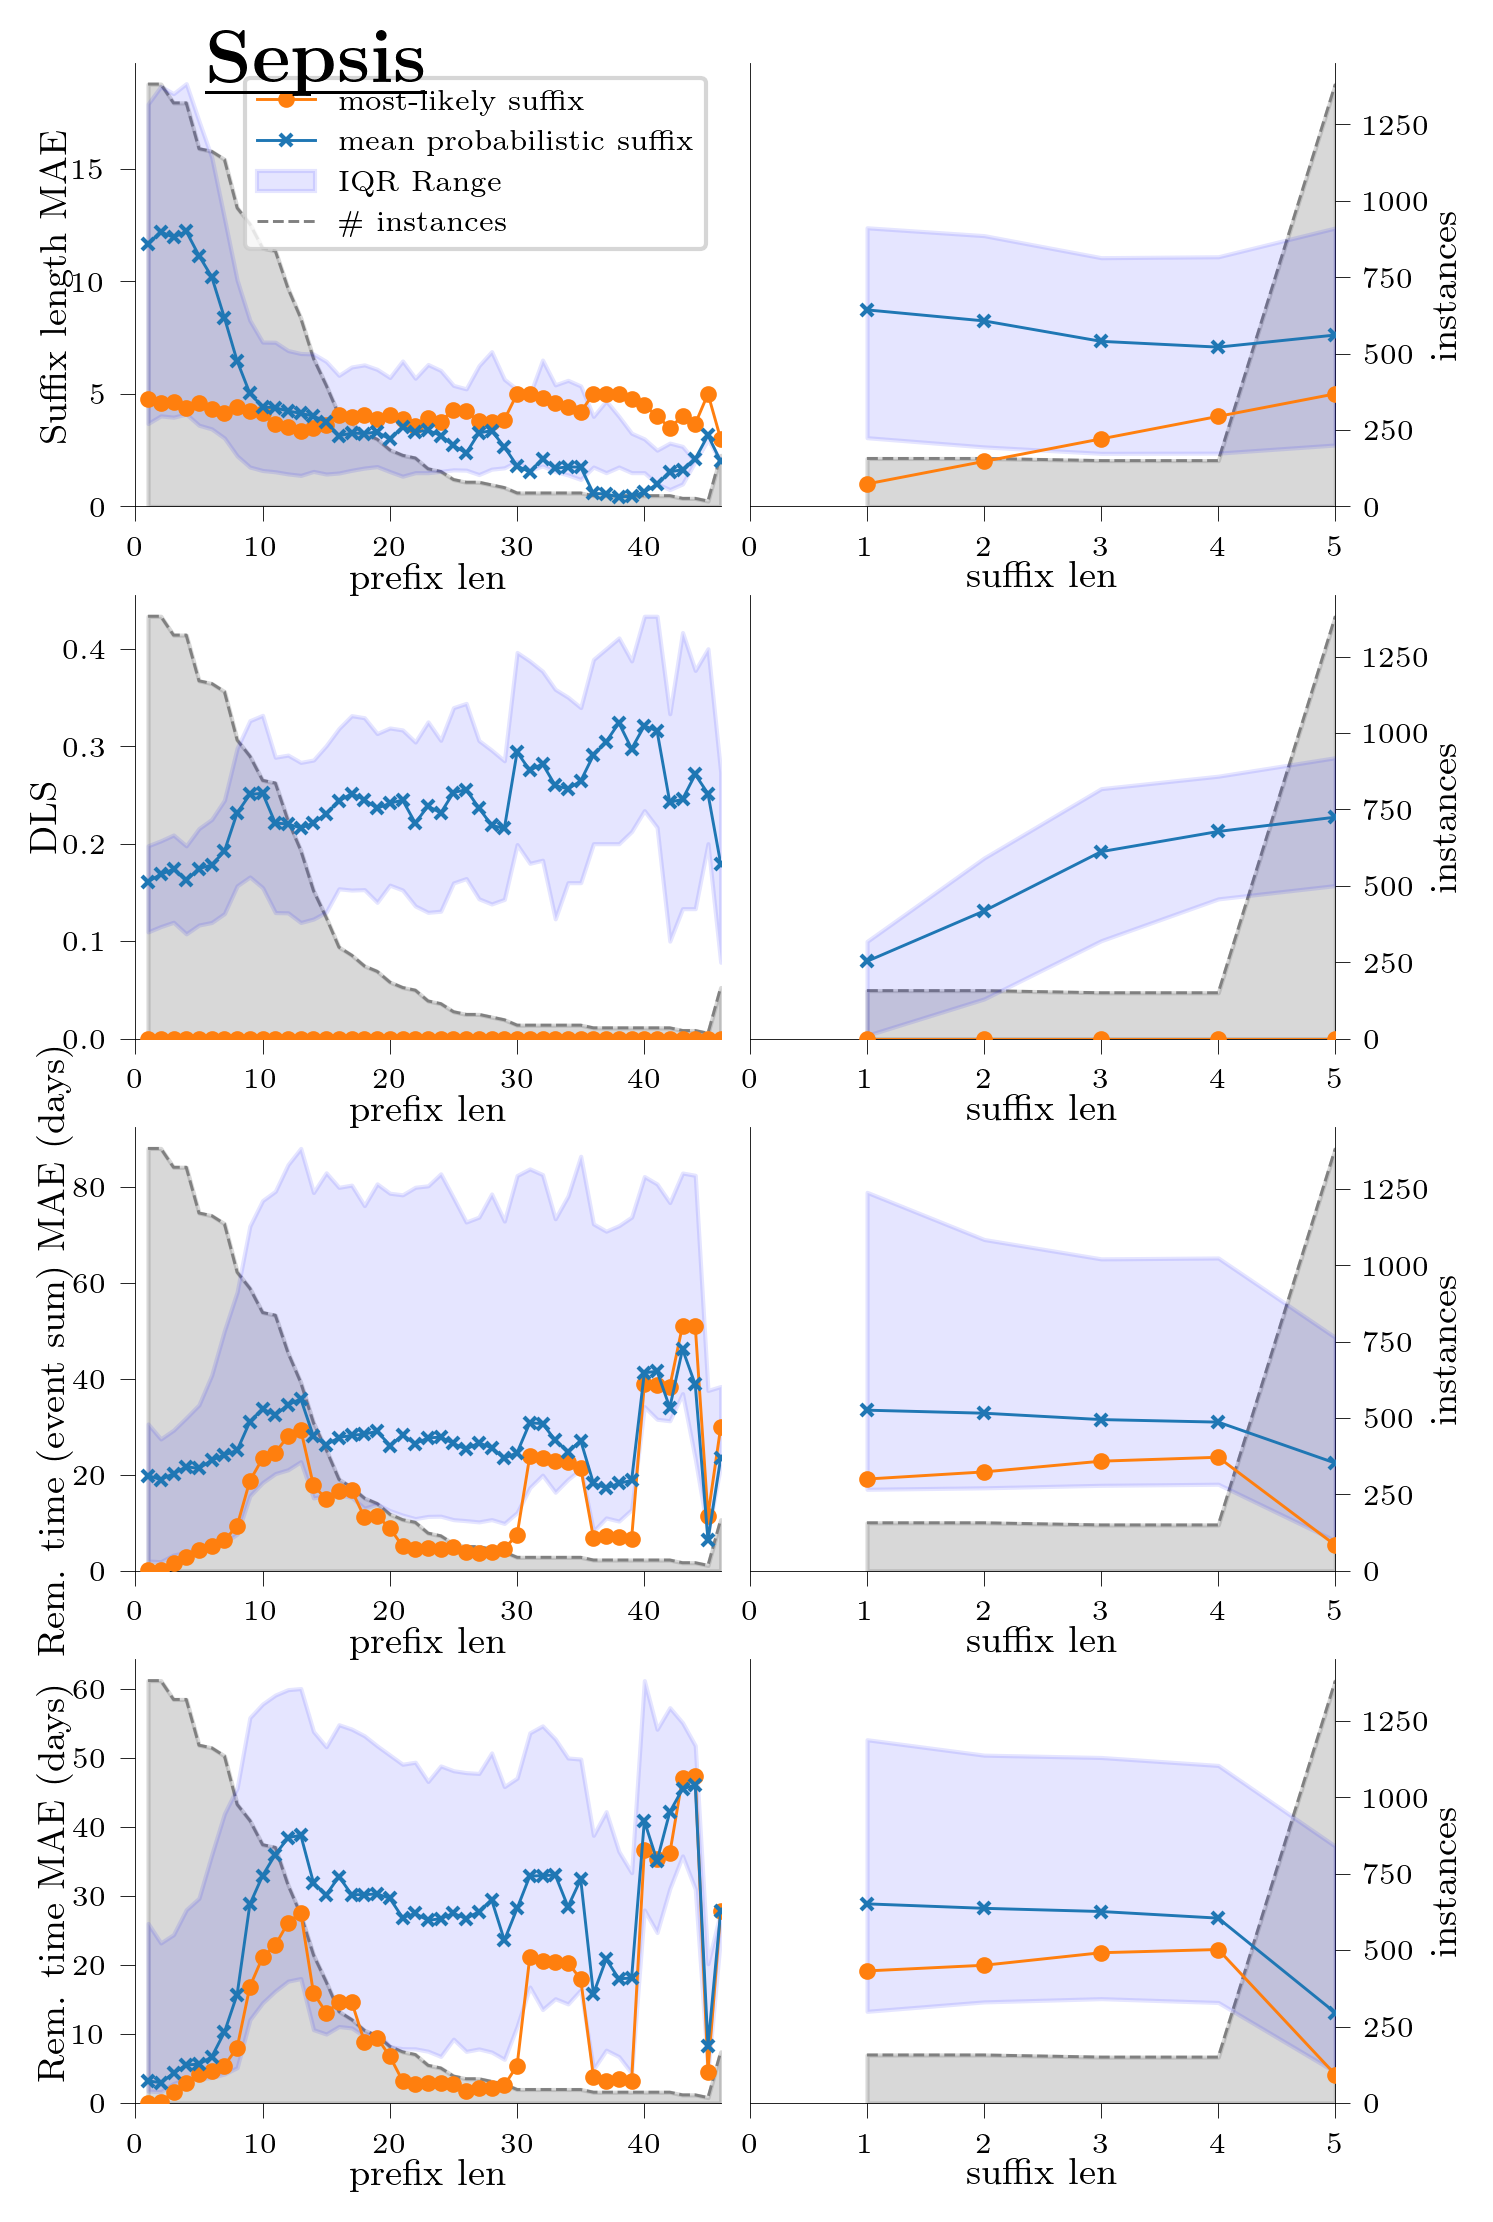

In [4]:
with open("Sepsis_eval.pkl", "rb") as file:
    all_results = pickle.load(file)

import src.evaluation_metrics.plots
importlib.reload(src.evaluation_metrics.plots)

res_raw, c = all_results['../../../../../../../data/Sepsis/v2_conformal/']

keys_to_keep = [
                ('SuffixCountMAE', 'Suffix length MAE'),
                ('NormalizedDamerauLevenshteinMeanVar_activity', 'DLS'),
                ('RemainingTime_SUM_Mean_MAE_outliers', 'Rem. time (event sum) MAE (days) '),
                ('RemainingTime_LastEvent_Mean2_Var_seconds_outliers', 'Rem. time MAE (days) ')
                # ('SuffixCountInterval_50', 'SuffixCountInterval_50'),
                # ('SuffixCountInterval_75', 'SuffixCountInterval_75'),
                # ('SuffixCountInterval_90', 'SuffixCountInterval_90'),
                # ('SuffixCountInterval_95', 'SuffixCountInterval_95'),
                # ('SuffixCountInterval_99', 'SuffixCountInterval_99'),

                # ('SumValuesInterval_50', 'SumValuesInterval_50'),
                # ('SumValuesInterval_75', 'SumValuesInterval_75'),
                # ('SumValuesInterval_90', 'SumValuesInterval_90'),
                # ('SumValuesInterval_95', 'SumValuesInterval_95'),
                # ('SumValuesInterval_99', 'SumValuesInterval_99'),

                # ('LastValueInterval_50', 'LastValueInterval_50'),
                # ('LastValueInterval_75', 'LastValueInterval_75'),
                # ('LastValueInterval_90', 'LastValueInterval_90'),
                # ('LastValueInterval_95', 'LastValueInterval_95'),
                # ('LastValueInterval_99', 'LastValueInterval_99'),
]

res = {(k, label) : res_raw[k] for k, label in keys_to_keep}
print(res_raw.keys())
print(len(res_raw.keys()))
print(len(res.keys()))
print(len(keys_to_keep))
print(res.keys())
p = src.evaluation_metrics.plots.plot_res(res, c, columns=2, caption='Sepsis', pgf=True) #int(len(keys_to_keep)))
with open('Sepsis.pgf', 'wb') as f:
    f.write(p)

In [5]:
print('Suffix length MAE')
print(np.mean([i['mean'] for i in res_raw['SuffixCountMAE'].values()]))
print('Probabilistic suffix length MAE')
print(np.mean([i['prob'][0] for i in res_raw['SuffixCountMAE'].values()]))

print('DLS')
print(np.mean([i['mean'] for i in res_raw['NormalizedDamerauLevenshteinMeanVar_activity'].values()]))
print('Probabilistic DLS')
print(np.mean([i['prob'][0] for i in res_raw['NormalizedDamerauLevenshteinMeanVar_activity'].values()]))

print('Mean MAE sum remaining time:')
print(np.mean([i['mean'] for i in res_raw['RemainingTime_SUM_Mean_MAE_outliers'].values()]))
print('Probabilistic MAE sum remaining time:')
print(np.mean([i['prob'][0] for i in res_raw['RemainingTime_SUM_Mean_MAE_outliers'].values()]))

print('Mean MAE last event:')
print(np.mean([i['mean'] for i in res_raw['RemainingTime_LastEvent_Mean2_Var_seconds_outliers'].values()]))
print('Probabilistic MAE last event:')
print(np.mean([i['prob'][0] for i in res_raw['RemainingTime_LastEvent_Mean2_Var_seconds_outliers'].values()]))


Suffix length MAE
4.2204328132863616
Probabilistic suffix length MAE
7.68790115656799
DLS
0.0
Probabilistic DLS
0.2041434548856834
Mean MAE sum remaining time:
10.33767219326362
Probabilistic MAE sum remaining time:
25.465085797744617
Mean MAE last event:
9.242166352367985
Probabilistic MAE last event:
17.638810526684154


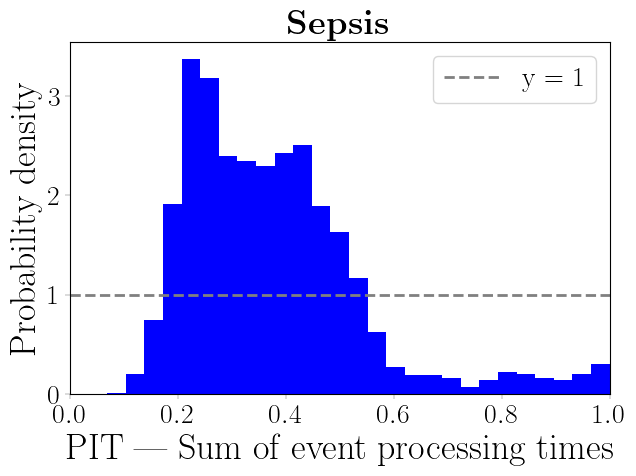

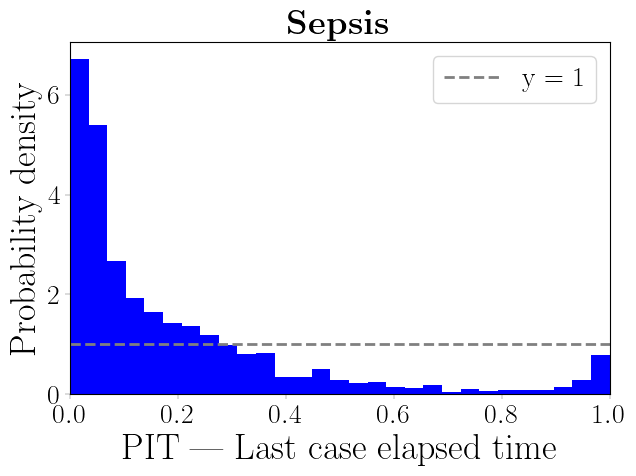

In [6]:
import src.evaluation_metrics.plots
importlib.reload(src.evaluation_metrics.plots)

with open('Sepsis_PIT_event_elapsed.pgf', 'wb') as f:
    r = src.evaluation_metrics.plots.plot_pits(res_raw['EventElapsed_PIT'], caption='Sepsis', x_label='Sum of event processing times', pgf=True)
    f.write(r)

with open('Sepsis_PIT_remaining_time.pgf', 'wb') as f:
    r = src.evaluation_metrics.plots.plot_pits(res_raw['RemainingTime_PIT'], caption='Sepsis', x_label='Last case elapsed time', pgf=True)
    f.write(r)